# Lennard-Jones vs. spring potential

## a. Plot the LJ and spring potential

Note:
- σ and ε are the constants for length and energy, so I measure lengths in units of σ and energies in units of ε. That means σ = ε = 1 in the code.
- The minimum of LJ is at r0 = 2^(1/6) σ, with V(r0) = -ε (derived in b).
- For the spring I use V = 1/2 k (r - r0)^2 - ε, so its minimum is at the same place as the LJ minimum. Therefore, I can compare them directly.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

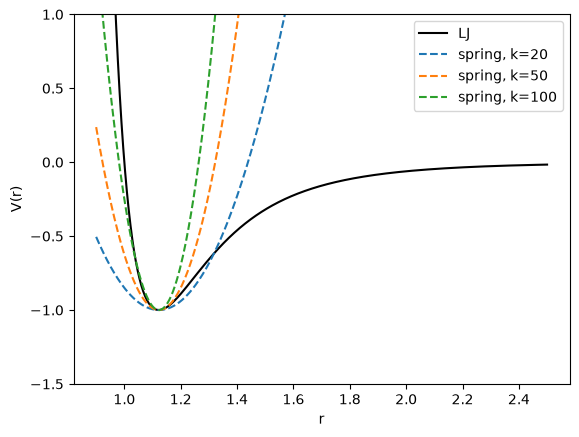

In [6]:
# Lennard-Jones potential: V_LJ(r) = 4*ε*[(σ/r)^12 - (σ/r)^6]
# σ and ε are the units of length and energy, so σ = 1 and ε = 1
# Minimum at r0 = 2^(1/6)*σ, where V = -ε (derived in b)
sigma, eps = 1, 1
r0 = 2**(1/6)*sigma

# Spring potential: V_spring(r) = 1/2*k*(r - r0)^2 - ε
# I shift it down by ε so its minimum is at the same point as the LJ minimum (that is why there is a -ε, just in case you are having a bad day)
# I will try 3 different spring constants: k = 20, 50, 100

# r goes from 0.9 to 2.5 (below 0.9 the LJ potential goes up very fast and ruins the plot)
r = np.linspace(0.9, 2.5, 500) #500 points between 0.9 and 2.5

V_LJ = 4*eps*((sigma/r)**12 - (sigma/r)**6) #look at the first line of the cell just in case you are having a bad day

# Plot LJ (black line) and the springs (dashed lines) in the same figure
fig, ax = plt.subplots()
ax.plot(r, V_LJ, 'k', label='LJ')
for k in [20, 50, 100]:
    ax.plot(r, 0.5*k*(r - r0)**2 - eps, '--', label=f'spring, k={k}') #one dashed line for each k
ax.set_ylim(-1.5, 1) #zoom in around the minimum, otherwise the steep parts take over the plot
ax.set_xlabel('r'); ax.set_ylabel('V(r)'); ax.legend()
plt.show()

Note:
- Both potentials have a minimum and it is a stable equilibrium.
- If a particle is pushed a bit away from the minimum, the force pushes it back, so it oscillates around the minimum.
- Close to the minimum the LJ potential looks like a parabola, just like the spring.
- Further away they are different. LJ is very steep for r < r0 and flattens to 0 for large r, so the bond can break. The spring, on the other hand, keeps growing.

## b. Small oscillations
Note:
- The particles are already bonded, so they sit at the minimum r0. A small push moves them a bit away, so r stays close to r0.
- When r is close to r0, I can Taylor expand V(r) around r0:

$$V(r) = V(r_0) + V'(r_0)\,(r - r_0) + \frac{1}{2}V''(r_0)\,(r - r_0)^2 + \frac{1}{6}V'''(r_0)\,(r - r_0)^3 + \dots$$

- Because r - r0 is small, (r - r0)^3 and higher powers are much smaller than (r - r0)^2. Therefore, I only keep the terms up to (r - r0)^2.
- So I need three things: V(r0), V'(r0) and V''(r0).

Step 1: the first derivative, and where the minimum is
- I write V with powers of r: V(r) = 4ε(σ^12 r^-12 - σ^6 r^-6). Then

$$V'(r) = 4\varepsilon\left(-\frac{12\sigma^{12}}{r^{13}} + \frac{6\sigma^{6}}{r^{7}}\right)$$

- At the minimum the slope is zero, so V'(r0) = 0. This means 12σ^12/r0^13 = 6σ^6/r0^7. Multiplying both sides by r0^13/(6σ^6) gives r0^6 = 2σ^6, so r0 = 2^(1/6) σ.
- Therefore, the (r - r0) term in the Taylor expansion is zero.

Step 2: the numbers I need at r0
- From step 1, r0^6 = 2σ^6. So (σ/r0)^6 = 1/2 and (σ/r0)^12 = 1/4.
- (In case that was too fast: r0 = 2^(1/6) σ, so σ/r0 = 2^(-1/6). Then (2^(-1/6))^6 = 2^(-1/6 · 6) = 2^(-1) = 1/2, because (a^b)^c = a^(b·c). Why? Because (a^b)^c means a^b multiplied by itself c times, and when you multiply powers of the same number you add the exponents, so you get a^(b + b + ... + b) with c times b, and b + b + ... + b (c times) is b·c, which is literally what multiplication means. For a fraction like 1/6 the rule still works, because 2^(1/6) is defined as the number that gives 2 when you multiply it by itself 6 times, which was chosen exactly so this rule keeps working. Then (σ/r0)^12 = ((σ/r0)^6)^2 = (1/2)^2 = 1/4, because 12 = 6·2 (I checked) and I use the same rule I just explained, just in case you are having a bad day.)

Step 3: V(r0)

$$V(r_0) = 4\varepsilon\left(\frac{1}{4} - \frac{1}{2}\right) = -\varepsilon$$

Step 4: the second derivative
- I differentiate V'(r) once more (-12·(-13) = 156 and 6·(-7) = -42):

$$V''(r) = 4\varepsilon\left(\frac{156\sigma^{12}}{r^{14}} - \frac{42\sigma^6}{r^8}\right)$$

- At r0 I use σ^12/r0^14 = (σ/r0)^12 · 1/r0^2 = 1/(4 r0^2) and σ^6/r0^8 = (σ/r0)^6 · 1/r0^2 = 1/(2 r0^2):

$$V''(r_0) = \frac{4\varepsilon}{r_0^2}\left(\frac{156}{4} - \frac{42}{2}\right) = \frac{4\varepsilon}{r_0^2}(39 - 21) = \frac{72\varepsilon}{r_0^2} = \frac{72\varepsilon}{2^{1/3}\sigma^2}$$

- The last step uses r0^2 = (2^(1/6) σ)^2 = 2^(1/3) σ^2.

Result: putting steps 1 to 4 into the Taylor expansion,

$$V(r) \approx -\varepsilon + \frac{1}{2}\cdot\frac{72\varepsilon}{2^{1/3}\sigma^2}(r - r_0)^2 = -\varepsilon + \frac{36\varepsilon}{2^{1/3}\sigma^2}(r - r_0)^2$$

Therefore, close to the minimum the LJ potential is a parabola, which is what we saw in the plot in a.

## c. Spring constant
Note:
- For a spring (harmonic oscillator) with rest length r0, the potential is V = 1/2 k (r - r0)^2 and the force is F = -dV/dr = -k (r - r0) (Hooke's law).
- From b, the LJ potential near the minimum is

$$V(r) \approx -\varepsilon + \frac{1}{2}V''(r_0)\,(r - r_0)^2$$

- The constant -ε does not change the force, because the derivative of a constant is 0 (just in case). So only the (r - r0)^2 term matters.
- Comparing the two term by term: 1/2 k = 1/2 V''(r0). Therefore,

$$k = V''(r_0) = \frac{72\varepsilon}{2^{1/3}\sigma^2} \approx 57.1\,\frac{\varepsilon}{\sigma^2}$$

- With σ = ε = 1 this is k ≈ 57.1. This matches the plot in a, where k = 50 already almost overlapped with LJ near the minimum.

## d. Two bonded masses

Note:
- The two masses are connected by a spring with the k from c. In equilibrium (first picture) the spring has its rest length, so there is no force.
- In the second picture m1 has moved r1 to the right and m2 has moved r2 to the left. They moved towards each other, so the spring is compressed by r1 + r2.
- A compressed spring pushes both masses back with Hooke's law, with force k(r1 + r2). m1 is pushed to the left (against r1) and m2 to the right (against r2).

Force equations (Newton's second law, F = ma, for each mass):

$$m_1\ddot{r}_1 = -k(r_1 + r_2)$$

$$m_2\ddot{r}_2 = -k(r_1 + r_2)$$

- The minus sign is there because the force points opposite to the displacement (just in case you are having a bad day).
- Both equations only depend on r1 + r2, so I turn them into one equation for x = r1 + r2. First I divide each equation by its mass:

$$\ddot{r}_1 = -\frac{k}{m_1}(r_1 + r_2), \qquad \ddot{r}_2 = -\frac{k}{m_2}(r_1 + r_2)$$

- Then I add them:

$$\ddot{r}_1 + \ddot{r}_2 = -k\left(\frac{1}{m_1} + \frac{1}{m_2}\right)(r_1 + r_2)$$

- With x = r1 + r2 and the reduced mass μ, defined by 1/μ = 1/m1 + 1/m2 (so μ = m1 m2/(m1 + m2)), this becomes

$$\ddot{x} = -\frac{k}{\mu}\,x$$

- x is how much the distance between the particles changed, so it is the same as r - r0 in b and c (up to a sign, which does not matter for a spring).
- This is the equation of a harmonic oscillator. Its solution is x(t) = A cos(ωt + φ). Putting it in gives ẍ = -ω^2 A cos(ωt + φ) = -ω^2 x, so ω^2 = k/μ.

Therefore, the particles oscillate with angular frequency ω and frequency f:

$$\omega = \sqrt{\frac{k}{\mu}}, \qquad f = \frac{\omega}{2\pi} = \frac{1}{2\pi}\sqrt{\frac{k}{\mu}}$$

With the LJ spring constant from c:

$$\omega = \sqrt{\frac{72\varepsilon}{2^{1/3}\sigma^2\mu}} \approx 7.56\sqrt{\frac{\varepsilon}{\sigma^2\mu}}$$

- Check: if m2 is very heavy (like a wall), then μ ≈ m1 and ω = sqrt(k/m1), which is the normal mass on a spring.